# Chapter 143 — Vector Transformations

> **Prerequisites:** ch142 (Coordinate Systems), ch139 (Basis and Dimension), ch125–126 (Addition, Scalar Multiplication), ch134 (Projections)  
> **You will learn:**
> - What a linear transformation is and how it relates to matrices
> - The geometric effect of linear transformations: scaling, rotation, shear, projection
> - How composition of transformations corresponds to matrix multiplication
> - The null space and range of a transformation and what they reveal
> - Why linear transformations are the core operation in neural networks
>
> **Environment:** Python 3.x, numpy, matplotlib

---

## 1. Concept

A **linear transformation** T: V → W is a function between vector spaces that preserves the two operations of vector algebra:

```
T(u + v) = T(u) + T(v)     (preserves addition)
T(cv)    = c·T(v)           (preserves scalar multiplication)
```

Together these mean T preserves all linear combinations:
```
T(c₁v₁ + c₂v₂ + ... + cₖvₖ) = c₁T(v₁) + c₂T(v₂) + ... + cₖT(vₖ)
```

**Every linear transformation from ℝⁿ to ℝᵐ is represented by an m×n matrix.** The matrix is constructed by recording where each standard basis vector lands: column j of the matrix is T(**eⱼ**).

**Common misconceptions:**
- "All functions are linear." False — f(x) = x² is not linear: f(2+3) = 25 ≠ 4 + 9.
- "Linear means the graph is a line." Linear here means *preserves linear combinations*, not that the output graph is a line.

---

## 2. Intuition & Mental Models

**Geometric model:** A linear transformation deforms space while keeping the origin fixed and straight lines straight. You can stretch, rotate, reflect, shear, and project — but not translate, curve, or fold. The transformation is completely determined by where the standard basis vectors land.

**Computational model:** A matrix A is a machine. Input: vector **x**. Output: A**x**. Column j of A is T(**eⱼ**) — the image of the j-th axis. Every output is a linear combination of the columns, weighted by the input coordinates.

Recall from ch139 (Basis): a linear map is fully determined by its action on a basis. The matrix encodes exactly that — it is the complete specification of the transformation.

**Physical analogy:** A linear transformation is like a rubber sheet you can stretch and rotate but not fold or cut. Points that were proportionally spaced stay proportionally spaced. Parallelograms map to parallelograms.

---

## 3. Visualization

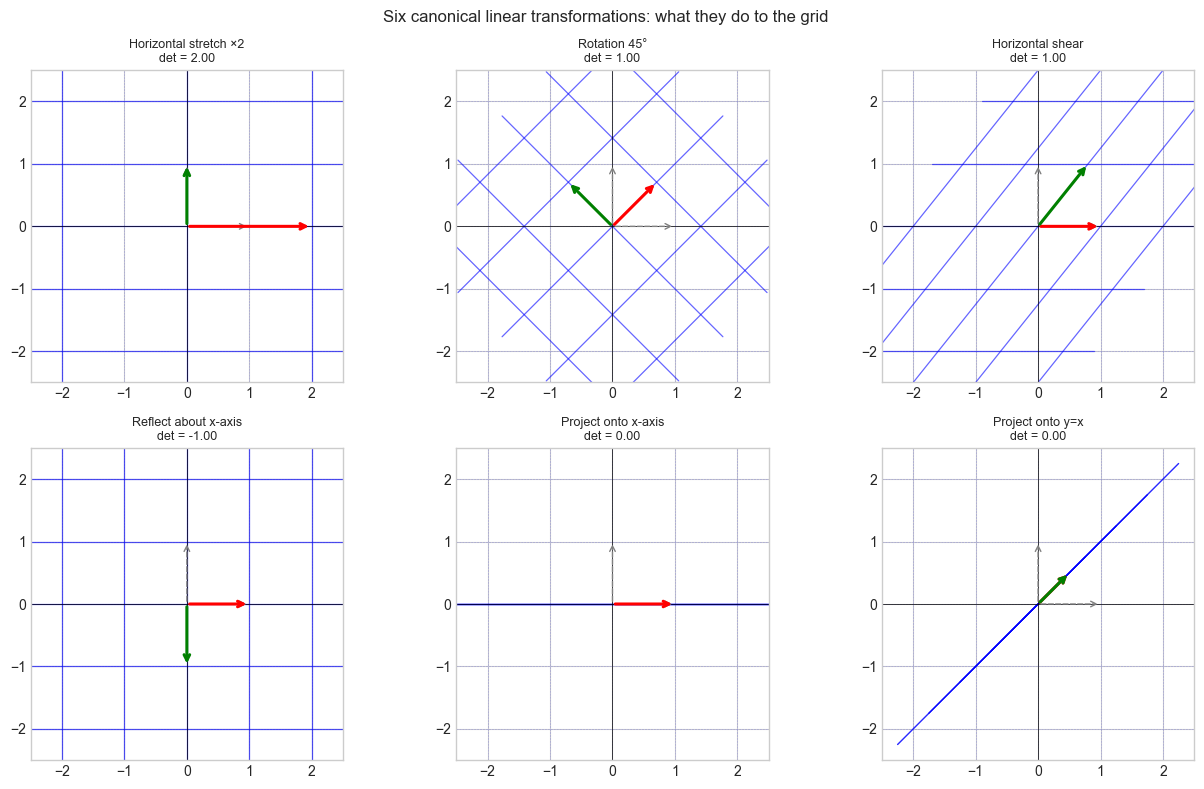

In [1]:
# --- Visualization: Effect of six canonical transformations on a grid ---

import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

def draw_transformed_grid(A, ax, title):
    """Draw original grid (dashed) and transformed grid (solid) under matrix A."""
    t = np.linspace(-2.5, 2.5, 300)
    for i in np.arange(-2, 3):
        # Original grid (dashed, light)
        ax.plot(t, np.full_like(t, i), 'b--', lw=0.4, alpha=0.25)
        ax.plot(np.full_like(t, i), t, 'b--', lw=0.4, alpha=0.25)
        # Transformed grid lines
        h = np.vstack([t, np.full_like(t, i)])
        v = np.vstack([np.full_like(t, i), t])
        th = A @ h
        tv = A @ v
        ax.plot(th[0], th[1], 'b-', lw=0.9, alpha=0.6)
        ax.plot(tv[0], tv[1], 'b-', lw=0.9, alpha=0.6)

    # Basis vectors before (gray) and after (colored)
    for e, c in [(np.array([1.,0.]),'red'), (np.array([0.,1.]),'green')]:
        ax.annotate('', xy=e, xytext=[0,0],
                    arrowprops=dict(arrowstyle='->', color='gray', lw=1, linestyle='dashed'))
        ax.annotate('', xy=A@e, xytext=[0,0],
                    arrowprops=dict(arrowstyle='->', color=c, lw=2.2))

    det = np.linalg.det(A)
    ax.set_xlim(-2.5, 2.5); ax.set_ylim(-2.5, 2.5)
    ax.set_title(f'{title}\ndet = {det:.2f}', fontsize=9)
    ax.axhline(0, color='k', lw=0.5); ax.axvline(0, color='k', lw=0.5)
    ax.set_aspect('equal')

fig, axes = plt.subplots(2, 3, figsize=(13, 8))

theta = np.pi / 4
transforms = [
    (np.array([[2.,0.],[0.,1.]]),                                     'Horizontal stretch ×2'),
    (np.array([[np.cos(theta),-np.sin(theta)],[np.sin(theta),np.cos(theta)]]), 'Rotation 45°'),
    (np.array([[1.,0.8],[0.,1.]]),                                    'Horizontal shear'),
    (np.array([[1.,0.],[0.,-1.]]),                                    'Reflect about x-axis'),
    (np.array([[1.,0.],[0.,0.]]),                                     'Project onto x-axis'),
    (np.array([[0.5,0.5],[0.5,0.5]]),                                 'Project onto y=x'),
]

for ax, (A, title) in zip(axes.flat, transforms):
    draw_transformed_grid(A, ax, title)

plt.suptitle('Six canonical linear transformations: what they do to the grid', fontsize=12)
plt.tight_layout()
plt.show()

---

## 4. Mathematical Formulation

**Representing T as a matrix:** Let T: ℝⁿ → ℝᵐ be linear. Then:
```
A = [T(e₁) | T(e₂) | ... | T(eₙ)]    (columns = images of standard basis vectors)
T(x) = Ax   for all x ∈ ℝⁿ
```

**Key properties:**
```
Null space:  N(A) = {x : Ax = 0}      — what gets collapsed to 0
Column space: C(A) = {Ax : x ∈ ℝⁿ}   — what can be reached
Rank:        dim(C(A))                — effective output dimension
Determinant: det(A)                   — signed volume scaling factor
```

**Composition = matrix multiplication:**
```
(T₂ ∘ T₁)(x) = A₂(A₁x) = (A₂A₁)x
```
Note: composition is generally not commutative — A₂A₁ ≠ A₁A₂.

**Standard 2D transformation matrices:**
```
Scale (sx, sy):    diag(sx, sy)
Rotate by θ:       [[cos θ, -sin θ], [sin θ, cos θ]]
Reflect x-axis:    [[1,0],[0,-1]]
Shear horizontal:  [[1,k],[0,1]]
Project x-axis:    [[1,0],[0,0]]
```

**Invertibility:** T invertible ⟺ det(A) ≠ 0 ⟺ rank(A) = n ⟺ N(A) = {**0**}.

---

## 5. Python Implementation

In [2]:
# --- Implementation: Linear transformation toolkit ---

import numpy as np


def rotation_2d(deg):
    """2D counter-clockwise rotation matrix."""
    t = np.radians(deg)
    return np.array([[np.cos(t), -np.sin(t)],
                     [np.sin(t),  np.cos(t)]])


def scale_2d(sx, sy):
    """2D non-uniform scaling matrix."""
    return np.array([[sx, 0.], [0., sy]])


def shear_2d(kx=0., ky=0.):
    """2D shear matrix. kx: horizontal shear, ky: vertical shear."""
    return np.array([[1., kx], [ky, 1.]])


def projection_onto(direction):
    """
    Projection matrix onto the subspace spanned by 'direction'.
    P = d dᵀ / (dᵀ d)
    """
    d = np.asarray(direction, dtype=float)
    return np.outer(d, d) / (d @ d)


def compose(*matrices):
    """
    Compose transformations left-to-right: compose(A, B, C) = C @ B @ A.
    (Apply A first, then B, then C.)
    """
    result = np.eye(matrices[0].shape[0])
    for M in matrices:
        result = M @ result
    return result


def transformation_summary(A):
    """
    Print key geometric properties of transformation matrix A.
    """
    sv = np.linalg.svd(A, compute_uv=False)
    rank = int(np.sum(sv > 1e-10))
    det = float(np.linalg.det(A)) if A.shape[0] == A.shape[1] else None
    print(f"  Shape: {A.shape}")
    print(f"  Rank: {rank}  |  Nullity: {A.shape[1]-rank}")
    if det is not None:
        print(f"  det = {det:.4f}  (area scaling = {abs(det):.4f})")
    print(f"  Singular values: {sv.round(4)}")
    print(f"  Invertible: {det is not None and abs(det) > 1e-10}")


# --- Verify linearity of a matrix transformation ---
def verify_linearity(A, n_trials=200, tol=1e-10):
    """
    Empirically verify T(au+bv) = aT(u) + bT(v) for random vectors and scalars.
    Returns True if all trials pass.
    """
    rng = np.random.default_rng(0)
    n = A.shape[1]
    for _ in range(n_trials):
        u = rng.standard_normal(n)
        v = rng.standard_normal(n)
        a, b = rng.standard_normal(2)
        lhs = A @ (a*u + b*v)
        rhs = a*(A@u) + b*(A@v)
        if np.linalg.norm(lhs - rhs) > tol:
            return False
    return True


# --- Demos ---
print("=== Rotation 45°:")
R = rotation_2d(45)
transformation_summary(R)
print(f"  Linearity verified: {verify_linearity(R)}")

print("\n=== Projection onto (1,1):")
P = projection_onto([1,1])
transformation_summary(P)
print(f"  Idempotent (P²=P): {np.allclose(P@P, P)}")

print("\n=== Composed: rotate 30° then scale (2, 0.5):")
C = compose(rotation_2d(30), scale_2d(2, 0.5))
transformation_summary(C)

=== Rotation 45°:
  Shape: (2, 2)
  Rank: 2  |  Nullity: 0
  det = 1.0000  (area scaling = 1.0000)
  Singular values: [1. 1.]
  Invertible: True
  Linearity verified: True

=== Projection onto (1,1):
  Shape: (2, 2)
  Rank: 1  |  Nullity: 1
  det = 0.0000  (area scaling = 0.0000)
  Singular values: [1. 0.]
  Invertible: False
  Idempotent (P²=P): True

=== Composed: rotate 30° then scale (2, 0.5):
  Shape: (2, 2)
  Rank: 2  |  Nullity: 0
  det = 1.0000  (area scaling = 1.0000)
  Singular values: [2.  0.5]
  Invertible: True


---

## 6. Experiments

C:\Users\user\AppData\Local\Temp\ipykernel_15104\342806594.py:33: UserWarning: Glyph 8728 (\N{RING OPERATOR}) missing from font(s) Arial.
  plt.tight_layout()
c:\Users\user\OneDrive\Documents\book\.venv\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8728 (\N{RING OPERATOR}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


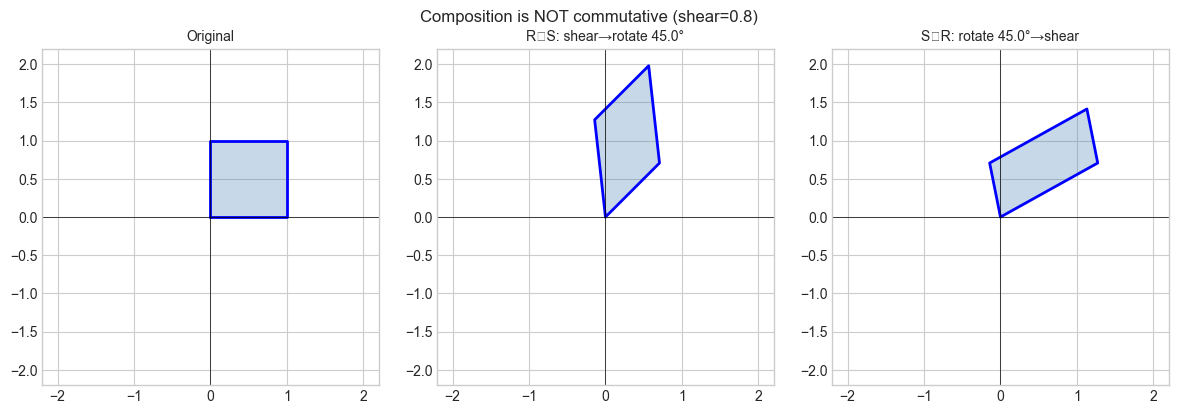

RS == SR: False


In [3]:
# --- Experiment 1: Composition is not commutative ---
# Hypothesis: rotate-then-shear != shear-then-rotate

import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

ANGLE = 45.0   # <-- modify
SHEAR = 0.8    # <-- modify

R = rotation_2d(ANGLE)
S = shear_2d(kx=SHEAR)
RS = R @ S   # shear first, then rotate
SR = S @ R   # rotate first, then shear

square = np.array([[0,0],[1,0],[1,1],[0,1],[0,0]], dtype=float).T

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, (M, title) in zip(axes, [
        (np.eye(2), 'Original'),
        (RS, f'R∘S: shear→rotate {ANGLE}°'),
        (SR, f'S∘R: rotate {ANGLE}°→shear')]):
    pts = M @ square
    ax.fill(pts[0], pts[1], alpha=0.3, color='steelblue')
    ax.plot(pts[0], pts[1], 'b-', lw=2)
    ax.set_xlim(-2.2, 2.2); ax.set_ylim(-2.2, 2.2)
    ax.set_title(title, fontsize=10)
    ax.axhline(0, color='k', lw=0.5); ax.axvline(0, color='k', lw=0.5)
    ax.set_aspect('equal')

plt.suptitle(f'Composition is NOT commutative (shear={SHEAR})', fontsize=12)
plt.tight_layout()
plt.show()
print(f"RS == SR: {np.allclose(RS, SR)}")

In [4]:
# --- Experiment 2: Determinant as area scaling ---
# Hypothesis: |det(A)| = area(A·parallelogram) / area(original parallelogram)

import numpy as np

def parallelogram_area(v1, v2):
    return abs(v1[0]*v2[1] - v1[1]*v2[0])

v1, v2 = np.array([1.0, 0.5]), np.array([0.3, 1.2])
orig_area = parallelogram_area(v1, v2)

print(f"Original area: {orig_area:.4f}\n")
print(f"{'Transform':>30}  {'|det|':>8}  {'area ratio':>10}  {'match':>6}")

for A, name in [
    (scale_2d(2, 1),      'Stretch x by 2'),
    (rotation_2d(60),     'Rotation 60°'),
    (np.array([[1.,0.],[0.,0.]]), 'Projection (rank 1)'),
    (np.array([[2.,1.],[1.,3.]]), 'General matrix'),
]:
    new_area = parallelogram_area(A@v1, A@v2)
    det = abs(np.linalg.det(A))
    ratio = new_area / orig_area
    print(f"  {name:>28}  {det:8.4f}  {ratio:10.4f}  {np.isclose(det,ratio)!s:>6}")

Original area: 1.0500

                     Transform     |det|  area ratio   match
                Stretch x by 2    2.0000      2.0000    True
                  Rotation 60°    1.0000      1.0000    True
           Projection (rank 1)    0.0000      0.0000    True
                General matrix    5.0000      5.0000    True


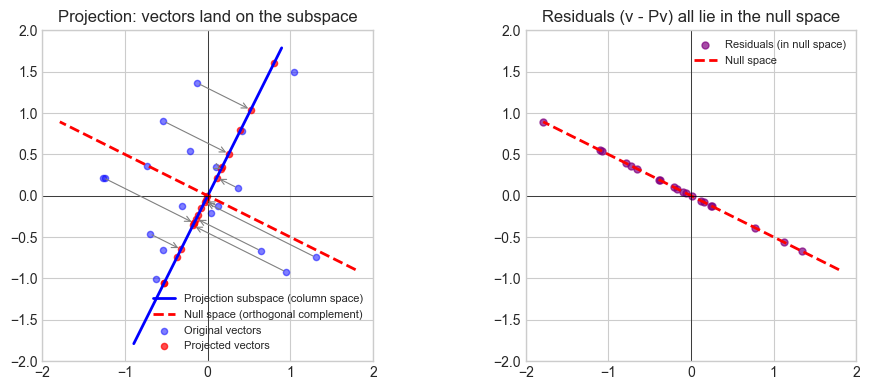

In [5]:
# --- Experiment 3: What the null space looks like geometrically ---
# Hypothesis: The null space of a projection is the orthogonal complement
# of the projection direction.

import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

DIRECTION = np.array([1.0, 2.0])  # <-- modify projection direction

P = projection_onto(DIRECTION)
d_unit = DIRECTION / np.linalg.norm(DIRECTION)
perp = np.array([-d_unit[1], d_unit[0]])  # orthogonal direction

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Sample vectors and their projections
rng = np.random.default_rng(0)
vecs = rng.standard_normal((2, 20))
proj_vecs = P @ vecs

ax = axes[0]
t = np.linspace(-2, 2, 100)
ax.plot(t*d_unit[0], t*d_unit[1], 'b-', lw=2, label='Projection subspace (column space)')
ax.plot(t*perp[0], t*perp[1], 'r--', lw=2, label='Null space (orthogonal complement)')
for i in range(10):
    ax.annotate('', xy=proj_vecs[:,i], xytext=vecs[:,i],
                arrowprops=dict(arrowstyle='->', color='gray', lw=0.8))
ax.scatter(vecs[0], vecs[1], c='blue', s=20, alpha=0.5, label='Original vectors')
ax.scatter(proj_vecs[0], proj_vecs[1], c='red', s=20, alpha=0.7, label='Projected vectors')
ax.set_xlim(-2, 2); ax.set_ylim(-2, 2)
ax.set_title('Projection: vectors land on the subspace')
ax.legend(fontsize=8)
ax.axhline(0, color='k', lw=0.5); ax.axvline(0, color='k', lw=0.5)
ax.set_aspect('equal')

ax2 = axes[1]
residuals = vecs - proj_vecs  # what gets sent to zero by P
ax2.scatter(residuals[0], residuals[1], c='purple', s=25, alpha=0.7, label='Residuals (in null space)')
ax2.plot(t*perp[0], t*perp[1], 'r--', lw=2, label='Null space')
ax2.set_xlim(-2, 2); ax2.set_ylim(-2, 2)
ax2.set_title('Residuals (v - Pv) all lie in the null space')
ax2.legend(fontsize=8)
ax2.axhline(0, color='k', lw=0.5); ax2.axvline(0, color='k', lw=0.5)
ax2.set_aspect('equal')

plt.tight_layout()
plt.show()

---

## 7. Exercises

**Easy 1.** Which of the following are linear transformations from ℝ² to ℝ²?
- (a) T(x,y) = (2x, 3y)
- (b) T(x,y) = (x+1, y)
- (c) T(x,y) = (x·y, x)
- (d) T(x,y) = (x−y, x+y)

*(Expected: a and d are linear; b translates; c multiplies)*

**Easy 2.** Write the matrix for: rotate 45° CCW, then scale x by 3. Apply it to **(1, 0)** and verify the result geometrically.

**Medium 1.** For the shear matrix `[[1, k], [0, 1]]`, compute the determinant for any k. What does this say about area preservation? What is the null space?

**Medium 2.** Implement `verify_linearity(f, n)` for an arbitrary Python function `f: R^n -> R^m` (not just matrices). Use it to confirm that `f(x) = x**2` is not linear.

**Hard.** Any 2×2 matrix A decomposes as A = UΣVᵀ (SVD). Show geometrically that this means every 2D linear transformation is: rotate (Vᵀ) → scale along axes (Σ) → rotate again (U). Write code to animate a unit circle being transformed step-by-step through this decomposition.

---

## 8. Mini Project

In [ ]:
# --- Mini Project: 2D Shape Transformation Pipeline ---
#
# Build a pipeline that applies a sequence of linear transformations
# to a polygon and visualizes each stage, tracking area scaling.

import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-whitegrid')

# House-shaped polygon
shape = np.array([
    [-1,0],[1,0],[1,1.2],[0,2],[-1,1.2],[-1,0]
], dtype=float).T

# Transformation pipeline — modify freely
pipeline = [
    (rotation_2d(30),      'Rotate 30°'),
    (scale_2d(1.5, 0.8),   'Scale (1.5, 0.8)'),
    (shear_2d(kx=0.4),     'Shear 0.4'),
]

stages = [('Original', shape.copy(), np.eye(2))]
current = shape.copy()
cumul = np.eye(2)
for A, label in pipeline:
    current = A @ current
    cumul = A @ cumul
    stages.append((label, current.copy(), cumul.copy()))

fig, axes = plt.subplots(1, len(stages), figsize=(4*len(stages), 5))
blues = plt.cm.Blues(np.linspace(0.35, 0.9, len(stages)))

for ax, (label, pts, M), color in zip(axes, stages, blues):
    ax.fill(pts[0], pts[1], color=color, alpha=0.65)
    ax.plot(pts[0], pts[1], 'k-', lw=1.5)
    det = np.linalg.det(M)
    ax.set_title(f'{label}\ndet={det:.3f}', fontsize=9)
    ax.set_xlim(-4, 4); ax.set_ylim(-3, 5)
    ax.axhline(0, color='k', lw=0.5); ax.axvline(0, color='k', lw=0.5)
    ax.set_aspect('equal')

plt.suptitle('Linear transformation pipeline — area scales with |det|', fontsize=12)
plt.tight_layout()
plt.show()

print("Cumulative determinants:")
for label, _, M in stages:
    print(f"  {label:20s}: det = {np.linalg.det(M):.4f}")

---

## 9. Chapter Summary & Connections

**What was covered:**
- A linear transformation preserves addition and scalar multiplication — equivalently, all linear combinations.
- Every linear map ℝⁿ → ℝᵐ is a matrix; the matrix columns are the images of the standard basis vectors.
- Composition of transformations = matrix multiplication (right-to-left).
- The determinant measures signed area/volume scaling; zero determinant means the transformation collapses a dimension.
- Null space = what gets crushed to zero; column space = what can be reached.

**Backward connection:** This is the operational form of ch142 (Coordinate Systems) *(introduced in ch142)*: a change of basis is a linear transformation. The basis change matrix is an invertible linear map.

**Forward connections:**
- In ch151 (Introduction to Matrices), matrices are studied as objects in their own right — but their geometric meaning is exactly what this chapter establishes.
- This will reappear in ch176 (Eigenvectors): eigenvectors are the special directions that a transformation merely scales — the fixed axes of the transformation.
- In ch188 (Linear Layers in Deep Learning), each layer is a linear transformation followed by a non-linearity. Understanding what the linear part does geometrically is prerequisite to understanding what the network learns.